In [1]:
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import cv2

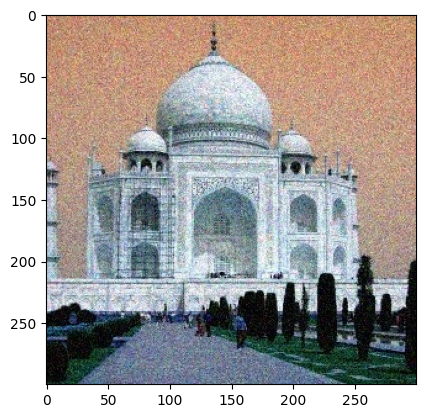

In [2]:
img = cv2.imread("/content/taj.jpg")
plt.imshow(img)

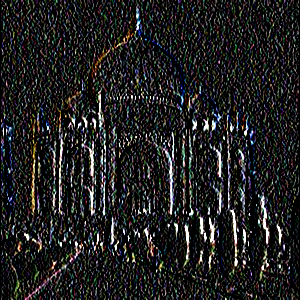

In [3]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
img1 = cv2.filter2D(img, -1, sobel_x)

cv2_imshow(img1)

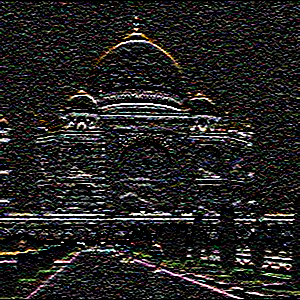

In [4]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
img2 = cv2.filter2D(img, -1, sobel_y)

cv2_imshow(img2)

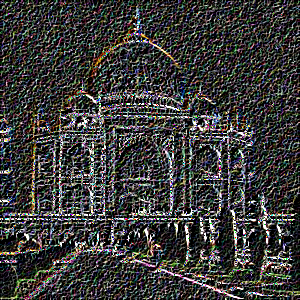

In [5]:
combsobel = img1 + img2
cv2_imshow(combsobel)

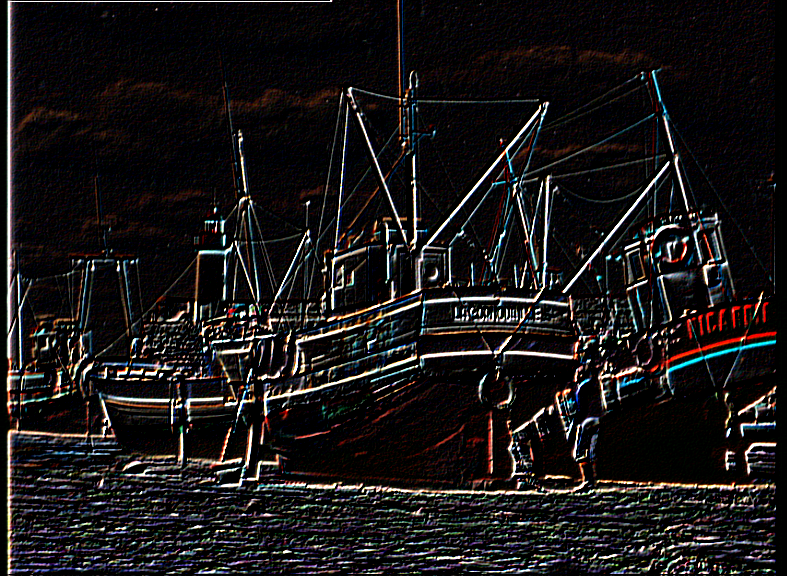

In [6]:
img3= cv2.imread("/content/BoatsColor.bmp")
finalsobel = sobel_x + sobel_y
img3 = cv2.filter2D(img3, -1, finalsobel)
cv2_imshow(img3)

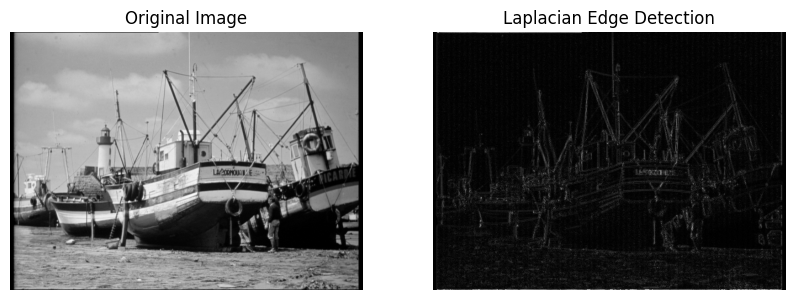

In [8]:
image = cv2.imread("/content/BoatsColor.bmp", cv2.IMREAD_GRAYSCALE)

# Apply the Laplacian operator
laplacian = cv2.Laplacian(image, cv2.CV_64F)  # 64-bit float to capture negative values
laplacian = np.uint8(np.absolute(laplacian))  # Convert to 8-bit

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian Edge Detection")
plt.axis("off")

plt.show()

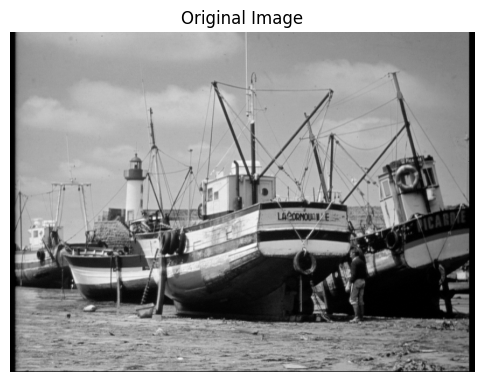

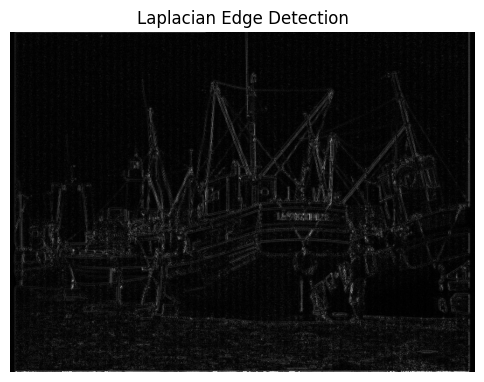

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("/content/BoatsColor.bmp", cv2.IMREAD_GRAYSCALE)


laplacian = cv2.Laplacian(image, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))


def show_image(img, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()


show_image(image, "Original Image")
show_image(laplacian, "Laplacian Edge Detection")

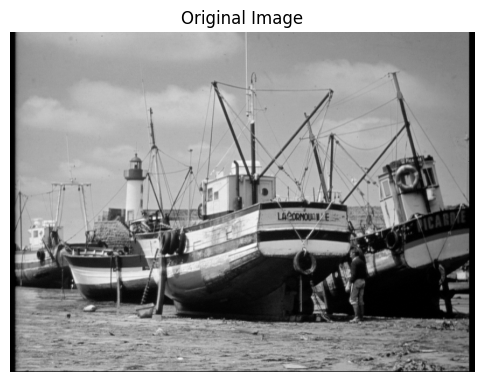

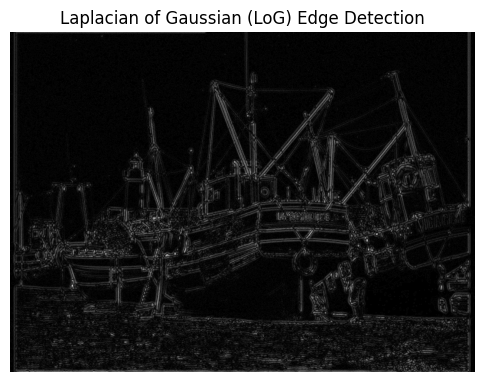

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/content/BoatsColor.bmp", cv2.IMREAD_GRAYSCALE)


blurred = cv2.GaussianBlur(image, (5, 5), 0)


log = cv2.Laplacian(blurred, cv2.CV_64F)
log = np.uint8(np.absolute(log))


def show_image(img, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image(image, "Original Image")
show_image(log, "Laplacian of Gaussian (LoG) Edge Detection")

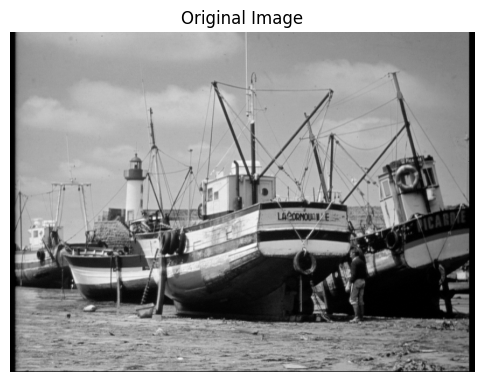

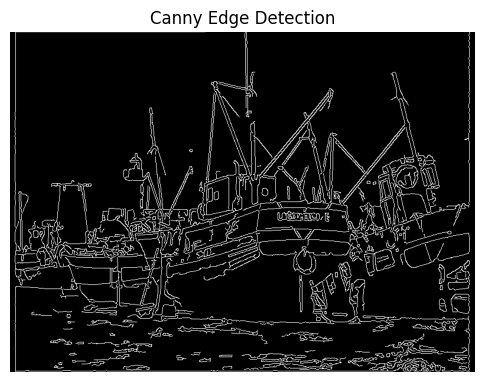

In [11]:


image = cv2.imread("/content/BoatsColor.bmp", cv2.IMREAD_GRAYSCALE)

blurred = cv2.GaussianBlur(image, (5, 5), 0)


edges = cv2.Canny(blurred, 50, 150)


show_image(image, "Original Image")
show_image(edges, "Canny Edge Detection")

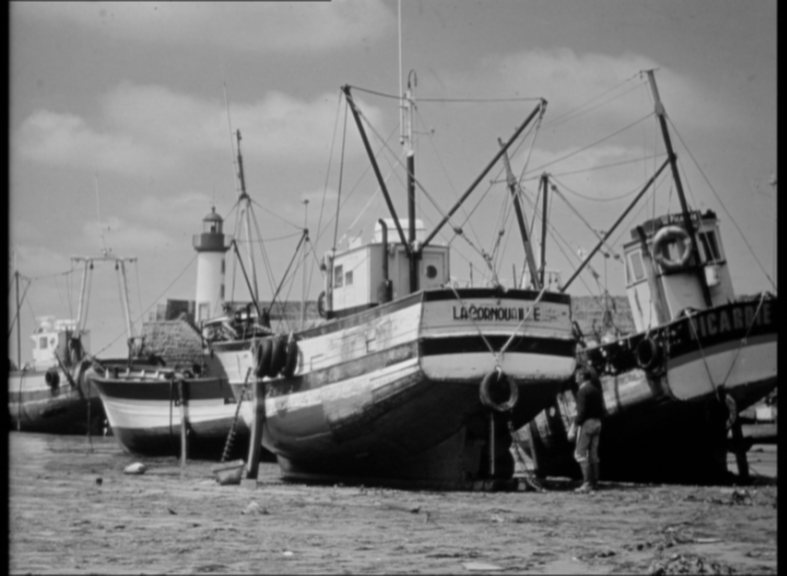

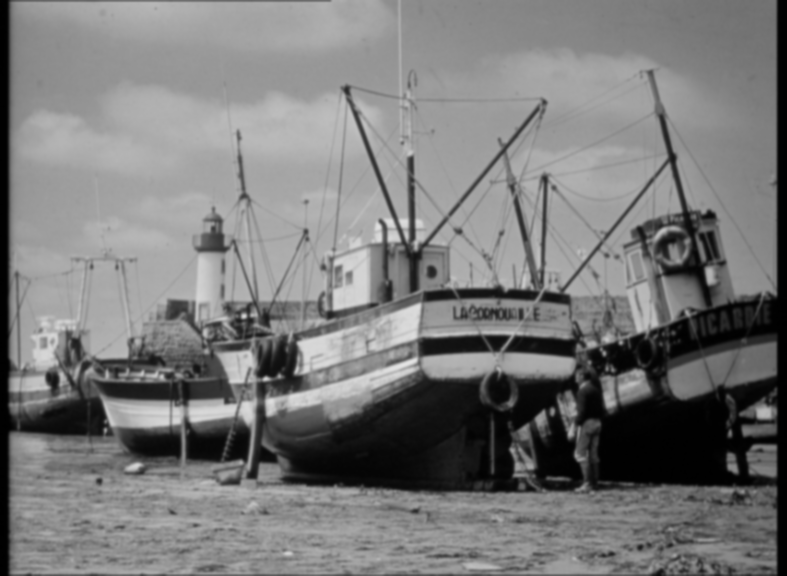

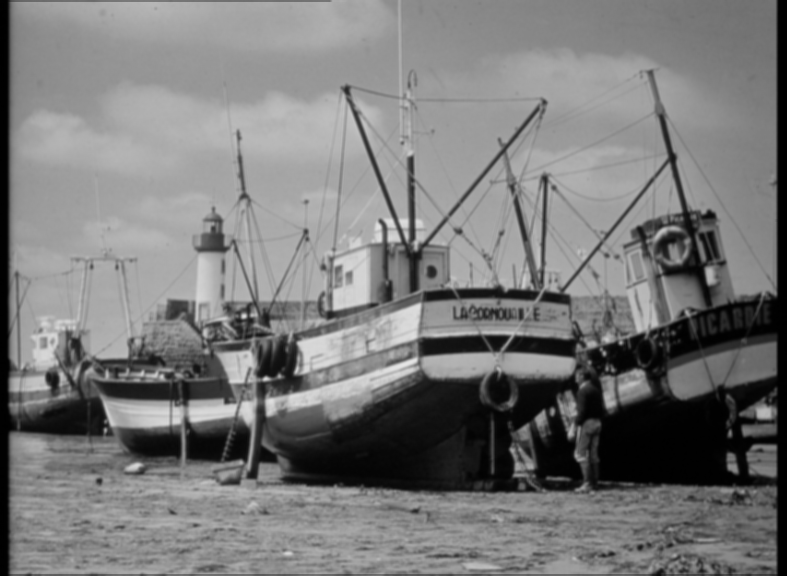

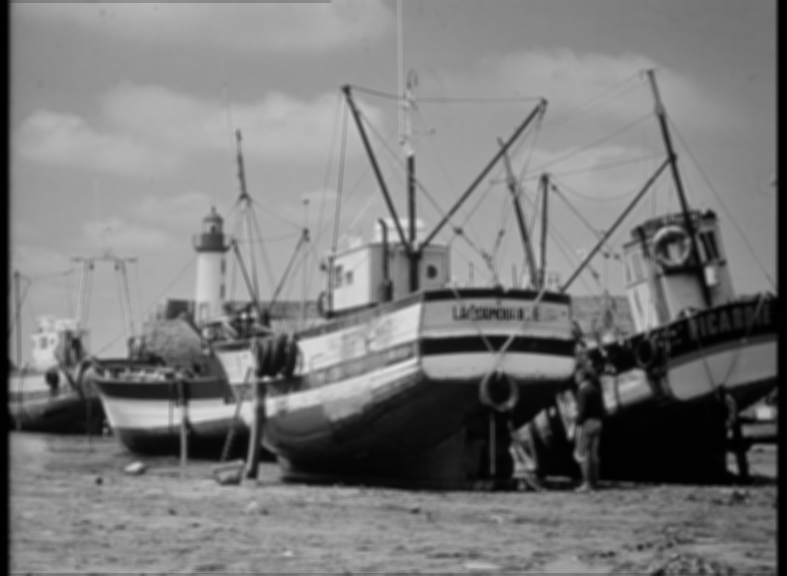

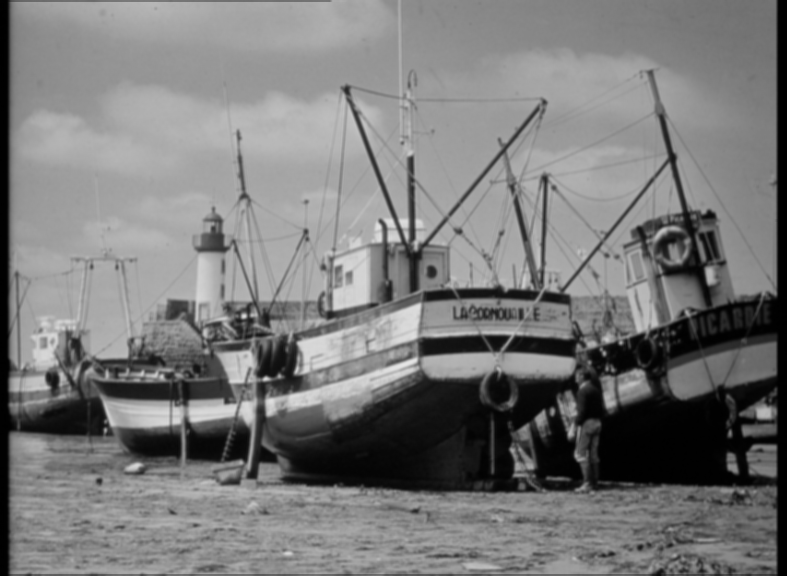

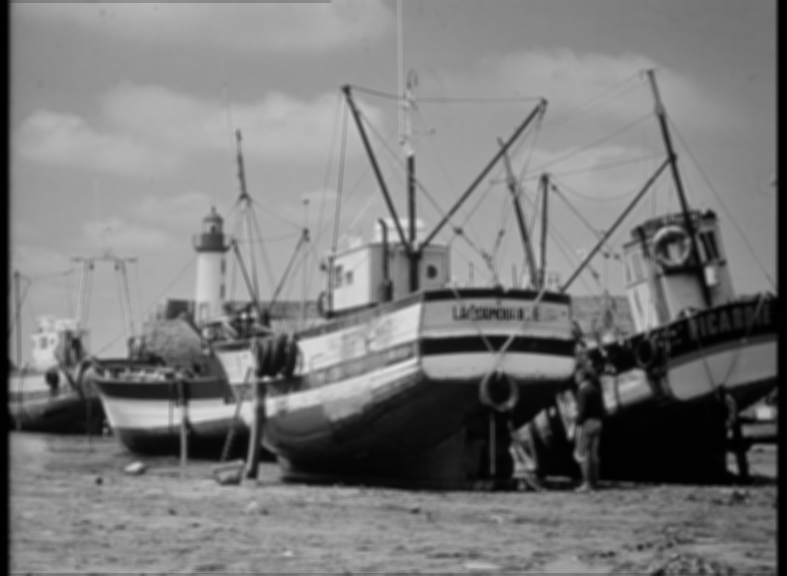

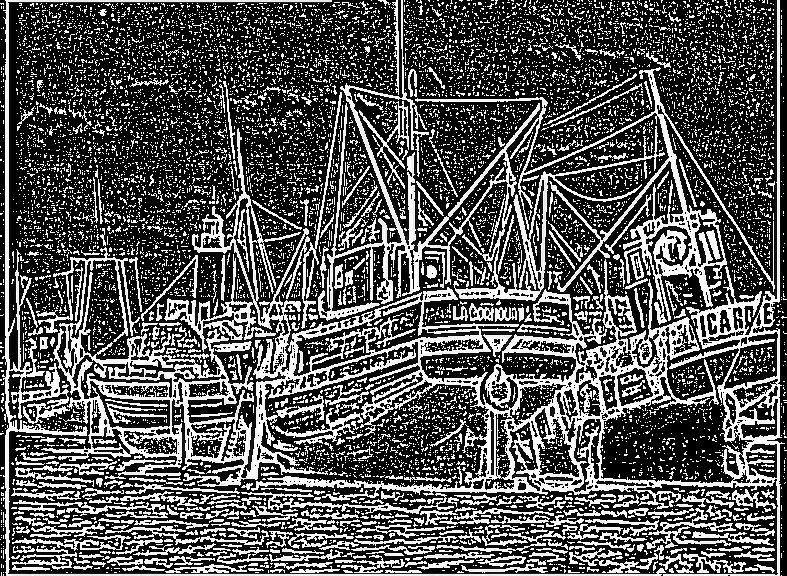

Gaussian Blur 3x3 sigma=0
Gaussian Blur 5x5 sigma=0
Gaussian Blur 3x3 sigma=10
Gaussian Blur 5x5 sigma=50
Gaussian Blur 3x3 sigma=50
Gaussian Blur 5x5 sigma=10
Difference of Gaussians


In [13]:
low_kernel = cv2.GaussianBlur(image,(3,3),0)
high_kernel = cv2.GaussianBlur(image,(5,5),0)
low_kernel_sigma = cv2.GaussianBlur(image,(3,3),10)
high_kernel_sigma = cv2.GaussianBlur(image,(5,5),50)
low_kernel_sigma1 = cv2.GaussianBlur(image,(3,3),50)
high_kernel_sigma1 = cv2.GaussianBlur(image,(5,5),10)
dog = low_kernel_sigma - high_kernel_sigma
cv2_imshow(low_kernel)
cv2_imshow(high_kernel)
cv2_imshow(low_kernel_sigma)
cv2_imshow(high_kernel_sigma)
cv2_imshow(low_kernel_sigma1)
cv2_imshow(high_kernel_sigma1)
cv2_imshow(dog)

print("Gaussian Blur 3x3 sigma=0")
print("Gaussian Blur 5x5 sigma=0")
print("Gaussian Blur 3x3 sigma=10")
print("Gaussian Blur 5x5 sigma=50")
print("Gaussian Blur 3x3 sigma=50")
print("Gaussian Blur 5x5 sigma=10")
print("Difference of Gaussians")

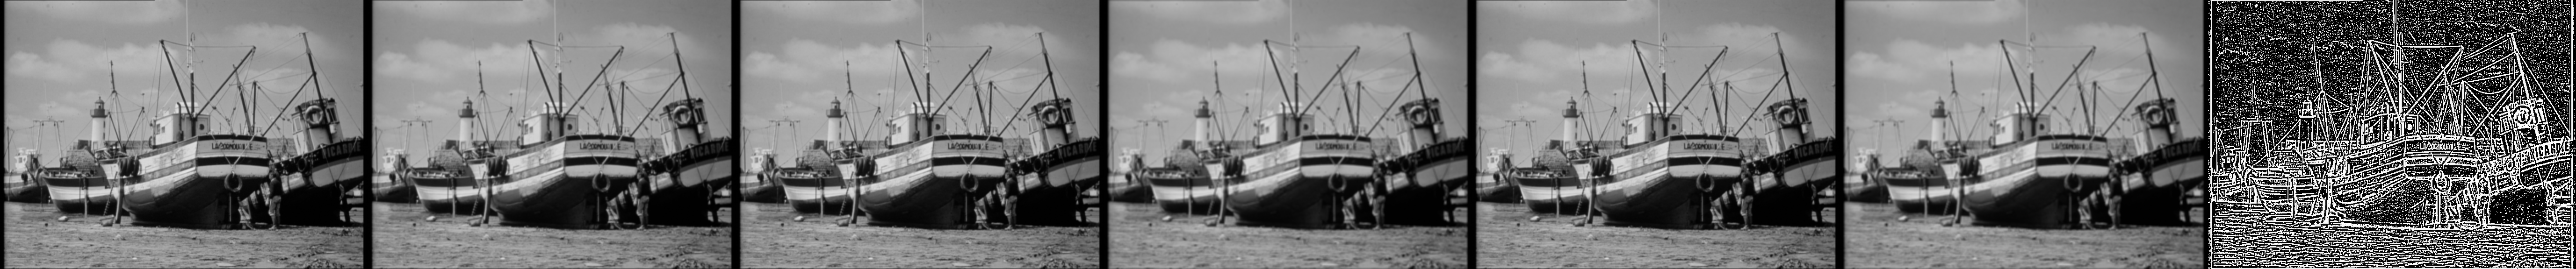

In [14]:
import cv2
import numpy as np


low_kernel = cv2.GaussianBlur(image, (3, 3), 0)
high_kernel = cv2.GaussianBlur(image, (5, 5), 0)
low_kernel_sigma = cv2.GaussianBlur(image, (3, 3), 10)
high_kernel_sigma = cv2.GaussianBlur(image, (5, 5), 50)
low_kernel_sigma1 = cv2.GaussianBlur(image, (3, 3), 50)
high_kernel_sigma1 = cv2.GaussianBlur(image, (5, 5), 10)
dog = low_kernel_sigma - high_kernel_sigma

height = min(image.shape[0], low_kernel.shape[0], high_kernel.shape[0], low_kernel_sigma.shape[0], high_kernel_sigma.shape[0], low_kernel_sigma1.shape[0], high_kernel_sigma1.shape[0], dog.shape[0])

images_resized = [
    cv2.resize(low_kernel, (int(low_kernel.shape[1] * height / low_kernel.shape[0]), height)),
    cv2.resize(high_kernel, (int(high_kernel.shape[1] * height / high_kernel.shape[0]), height)),
    cv2.resize(low_kernel_sigma, (int(low_kernel_sigma.shape[1] * height / low_kernel_sigma.shape[0]), height)),
    cv2.resize(high_kernel_sigma, (int(high_kernel_sigma.shape[1] * height / high_kernel_sigma.shape[0]), height)),
    cv2.resize(low_kernel_sigma1, (int(low_kernel_sigma1.shape[1] * height / low_kernel_sigma1.shape[0]), height)),
    cv2.resize(high_kernel_sigma1, (int(high_kernel_sigma1.shape[1] * height / high_kernel_sigma1.shape[0]), height)),
    cv2.resize(dog, (int(dog.shape[1] * height / dog.shape[0]), height))
]


output_image = np.hstack(images_resized)

cv2_imshow( output_image)
